In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from scipy.interpolate import interp1d


In [3]:
# network_C_ratio = np.load('outputs/network_ratio/round_wise_data/rounds_total_C_ratio_per_step_20_20_10_0.25.npy')
# network_pair_actions = np.load('outputs/network_ratio/round_wise_data/rounds_total_pair_actions_20_20_10_0.25.npy', allow_pickle=True)
# network_rewards = np.load('outputs/network_ratio/round_wise_data/rounds_total_reward_20_20_10_0.25.npy', allow_pickle=True)
# num_of_connections = [44, 50, 49, 49, 53, 53, 47, 45, 50, 46]

# network_rewards_per_connection = list(map(lambda x, y: x/y, network_rewards, num_of_connections))
# network_rewards_per_connection = np.array(network_rewards_per_connection)

# re-run the 8th round for removing the outlier
# read the new data
network_C_ratio = pd.read_csv('NR_C_ratio-modified.csv')
# change the pair actions for the 8th round to this array: [{'CC': 11, 'CD': 11, 'DC': 15, 'DD': 7}, {'CC': 11, 'CD': 8, 'DC': 11, 'DD': 14}, {'CC': 18, 'CD': 4, 'DC': 2, 'DD': 20}, {'CC': 30, 'CD': 2, 'DC': 4, 'DD': 8}, {'CC': 32, 'CD': 2, 'DC': 4, 'DD': 6}, {'CC': 34, 'CD': 1, 'DC': 3, 'DD': 6}, {'CC': 35, 'CD': 1, 'DC': 2, 'DD': 6}, {'CC': 36, 'CD': 2, 'DC': 2, 'DD': 4}, {'CC': 38, 'CD': 0, 'DC': 2, 'DD': 4}, {'CC': 39, 'CD': 1, 'DC': 1, 'DD': 3}, {'CC': 41, 'CD': 1, 'DC': 0, 'DD': 2}, {'CC': 43, 'CD': 0, 'DC': 0, 'DD': 1}, {'CC': 44, 'CD': 0, 'DC': 0, 'DD': 0}, {'CC': 44, 'CD': 0, 'DC': 0, 'DD': 0}, {'CC': 44, 'CD': 0, 'DC': 0, 'DD': 0}, {'CC': 44, 'CD': 0, 'DC': 0, 'DD': 0}, {'CC': 44, 'CD': 0, 'DC': 0, 'DD': 0}, {'CC': 44, 'CD': 0, 'DC': 0, 'DD': 0}, {'CC': 44, 'CD': 0, 'DC': 0, 'DD': 0}, {'CC': 44, 'CD': 0, 'DC': 0, 'DD': 0}]
network_pair_actions = np.load('outputs/network_ratio/round_wise_data/rounds_total_pair_actions_20_20_10_0.25.npy', allow_pickle=True)
network_pair_actions[7] = [{'CC': 11, 'CD': 11, 'DC': 15, 'DD': 7}, {'CC': 11, 'CD': 8, 'DC': 11, 'DD': 14}, {'CC': 18, 'CD': 4, 'DC': 2, 'DD': 20}, {'CC': 30, 'CD': 2, 'DC': 4, 'DD': 8}, {'CC': 32, 'CD': 2, 'DC': 4, 'DD': 6}, {'CC': 34, 'CD': 1, 'DC': 3, 'DD': 6}, {'CC': 35, 'CD': 1, 'DC': 2, 'DD': 6}, {'CC': 36, 'CD': 2, 'DC': 2, 'DD': 4}, {'CC': 38, 'CD': 0, 'DC': 2, 'DD': 4}, {'CC': 39, 'CD': 1, 'DC': 1, 'DD': 3}, {'CC': 41, 'CD': 1, 'DC': 0, 'DD': 2}, {'CC': 43, 'CD': 0, 'DC': 0, 'DD': 1}, {'CC': 44, 'CD': 0, 'DC': 0, 'DD': 0}, {'CC': 44, 'CD': 0, 'DC': 0, 'DD': 0}, {'CC': 44, 'CD': 0, 'DC': 0, 'DD': 0}, {'CC': 44, 'CD': 0, 'DC': 0, 'DD': 0}, {'CC': 44, 'CD': 0, 'DC': 0, 'DD': 0}, {'CC': 44, 'CD': 0, 'DC': 0, 'DD': 0}, {'CC': 44, 'CD': 0, 'DC': 0, 'DD': 0}, {'CC': 44, 'CD': 0, 'DC': 0, 'DD': 0}]
# change the network_rewards[7] to this array: [210, 189, 178, 226, 234, 236, 237, 244, 246, 250, 255, 260, 264, 264, 264, 264, 264, 264, 264, 264]
network_rewards = np.load('outputs/network_ratio/round_wise_data/rounds_total_reward_20_20_10_0.25.npy', allow_pickle=True)
network_rewards[7] = [210, 189, 178, 226, 234, 236, 237, 244, 246, 250, 255, 260, 264, 264, 264, 264, 264, 264, 264, 264]
num_of_connections = [44, 50, 49, 49, 53, 53, 47, 44, 50, 46]

network_rewards_per_connection = list(map(lambda x, y: x/y, network_rewards, num_of_connections))
network_rewards_per_connection = np.array(network_rewards_per_connection)

In [4]:
network_pair_actions.shape

(10, 20)

In [5]:
# save this numpy ndarray to a csv
network_C_ratio_df = pd.DataFrame(network_C_ratio)
network_C_ratio_df.to_csv('NR_C_ratio.csv', index=False)

# read network c ratio copy
# network_C_ratio = pd.read_csv('NR_C_ratio-modified.csv')
# get the mean and std for every column of network_C_ratio
network_C_ratio_mean = np.mean(network_C_ratio, axis=0)
network_C_ratio_std = np.std(network_C_ratio, axis=0)
print(network_C_ratio_mean.mean(), network_C_ratio_std.mean())

0.8226000000000001 0.08883001286964173


In [16]:
all_data = {}
scenarios = ['RL', 'LA+AR', 'LA']
for name in scenarios:
    if "+" in name:
        filename = name.split("+")[1]
    else:
        filename = name
    df = pd.read_csv(f'outputs/{filename}.csv')
    all_data[name] = df

In [17]:
for name, df in all_data.items():
    print(name)

RL
LA+AR
LA


In [18]:
def convert_csv_column_to_numpy(column_name):
    column = df[column_name]
    column = column.to_numpy()
    column = [eval(x) for x in column]
    column = np.array(column)
    return column

all_data_dict = {}
for name, df in all_data.items():
    for column in ['C ratio per steps', 'Rewards', 'Pair actions', 'Aggregated C ratio']:
        all_data_dict[f'{name}_{column}'] = convert_csv_column_to_numpy(column)
    # divide all data in Rewards list by Number of connections to get reward per connection
    # and add it to the dictionary
    all_data_dict[f'{name}_reward_per_connection'] = list(map(lambda x, y: x/y, all_data_dict[f'{name}_Rewards'], df['Number of connections']))


all_data_dict.keys()

dict_keys(['RL_C ratio per steps', 'RL_Rewards', 'RL_Pair actions', 'RL_Aggregated C ratio', 'RL_reward_per_connection', 'LA+AR_C ratio per steps', 'LA+AR_Rewards', 'LA+AR_Pair actions', 'LA+AR_Aggregated C ratio', 'LA+AR_reward_per_connection', 'LA_C ratio per steps', 'LA_Rewards', 'LA_Pair actions', 'LA_Aggregated C ratio', 'LA_reward_per_connection'])

0.8226000000000001
NR: y: 0.8226000000000001
RL_C ratio per steps: y: 0.88055
LA+AR_C ratio per steps: y: 0.11355000000000001
LA_C ratio per steps: y: 0.6200500000000001


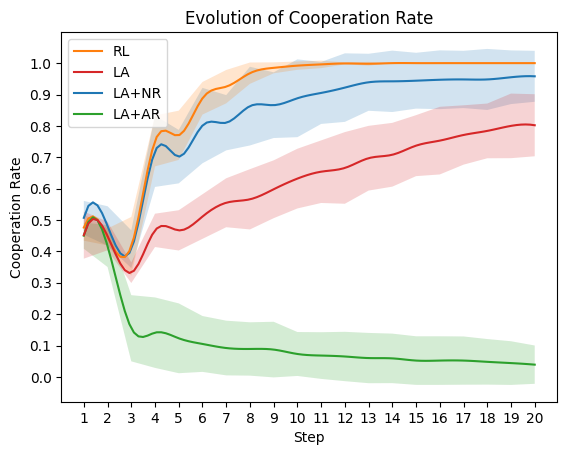

In [24]:
# plot network_C_ratio and c_ratio_per_steps_data.mean(axis=0) in the same plot
x = range(1, 21)
y = network_C_ratio.mean(axis=0)
print(y.mean())
f = interp1d(x, y, kind='cubic')
x_smooth = np.linspace(1, 20, 100)
y_smooth = f(x_smooth)
plt.plot(x_smooth, y_smooth, label='LA+NR')
std = network_C_ratio.std(axis=0)
# plt.plot(x, y, label='NR')
plt.fill_between(x, y-std, y+std, alpha=0.2)
print(f'NR: y: {y.mean()}')
for name in all_data_dict.keys():
    if 'C ratio per steps' in name:
        y = all_data_dict[name].mean(axis=0)
        print(f'{name}: y: {y.mean()}')
        f = interp1d(x, y, kind='cubic')
        x_smooth = np.linspace(1, 20, 100)
        y_smooth = f(x_smooth)
        plt.plot(x_smooth, y_smooth, label=name.split('_')[0])
        std = all_data_dict[name].std(axis=0)
        # plt.plot(x, y, label=name.split('_')[0])
        # make the plot curved
        
        plt.fill_between(x, y-std, y+std, alpha=0.2)

# change the order of plots in the legend
handles, labels = plt.gca().get_legend_handles_labels()
order = [1, 3, 0, 2]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc='upper left')

# plt.legend()
plt.xlabel('Step')
plt.ylabel('Cooperation Rate')
plt.title(f'Evolution of Cooperation Rate')
# make the x axis show integer only
plt.xticks(np.arange(1, 21, 1.0))
# make the y axis show 2 decimal places
plt.yticks(np.arange(0, 1.1, 0.1))
plt.savefig(os.path.join('figs/', f'C_ratio_evolution_curved.png'))
# save in pdf
plt.savefig(os.path.join('figs/', f'C_ratio_evolution_curved.pdf'))
plt.show()

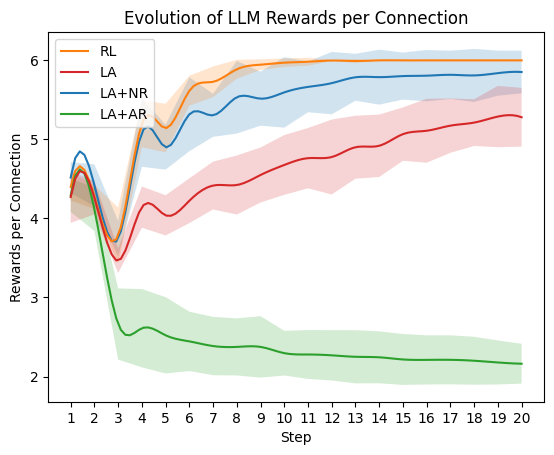

In [39]:
# plotting rewards per connection
x = range(1, 21)
y = network_rewards_per_connection.mean(axis=0)
std = network_rewards_per_connection.std(axis=0)
# plt.plot(x, y, label='NR')

f = interp1d(x, y, kind='cubic')
x_smooth = np.linspace(1, 20, 100)
y_smooth = f(x_smooth)
plt.plot(x_smooth, y_smooth, label='LA+NR')
plt.fill_between(x, y-std, y+std, alpha=0.2)
for name in all_data_dict.keys():
    if 'reward_per_connection' in name:
        all_data_dict[name] = np.array(all_data_dict[name])
        y = all_data_dict[name].mean(axis=0)
        f = interp1d(x, y, kind='cubic')
        x_smooth = np.linspace(1, 20, 100)
        y_smooth = f(x_smooth)
        plt.plot(x_smooth, y_smooth, label=name.split('_')[0])
        std = all_data_dict[name].std(axis=0)
        # plt.plot(x, y, label=name.split('_')[0])
        plt.fill_between(x, y-std, y+std, alpha=0.2)

# change the order of plots in the legend
handles, labels = plt.gca().get_legend_handles_labels()
order = [1, 3, 0, 2]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order], loc='upper left')
plt.xlabel('Step')
plt.ylabel('Rewards per Connection')
plt.title(f'Evolution of LLM Rewards per Connection')
# make the x axis show integer only
plt.xticks(np.arange(1, 21, 1.0))
plt.savefig(os.path.join('figs/', f'Rewards_per_connection_evolution_curved.png'))
plt.show()

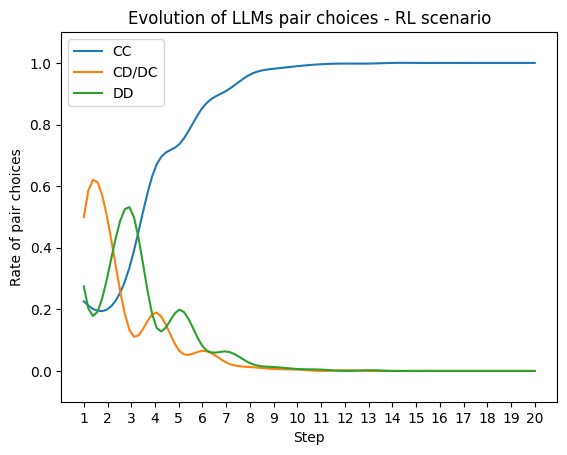

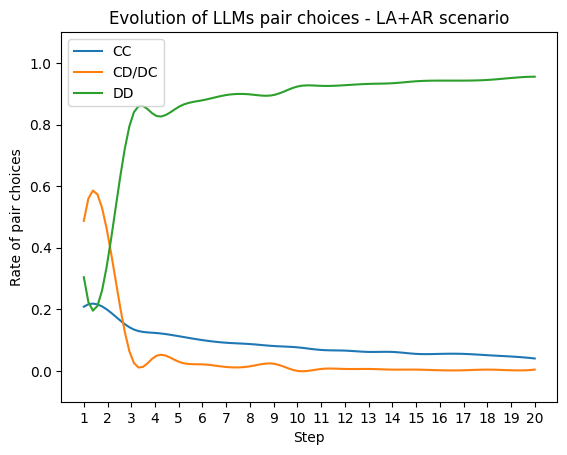

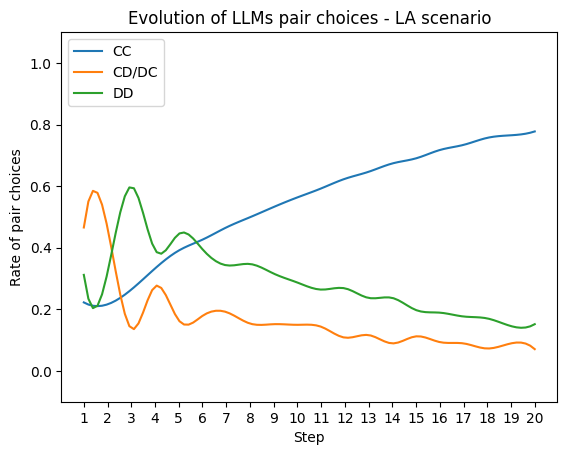

In [35]:
# plot pair actions for RL
scenarios = ['RL', 'LA+AR', 'LA']
for scenario in scenarios:
    pair_actions = all_data_dict[f'{scenario}_Pair actions']

    CC_list = []
    CD_list = []
    DC_list = []
    DD_list = []
    # CD_or_DC_list = []

    for i in range(np.shape(pair_actions)[0]):
        CC_list_tem = []
        CD_list_tem = []
        DC_list_tem = []
        DD_list_tem = []
        for j in range(np.shape(pair_actions)[1]):
            CC_list_tem.append(pair_actions[i,j]['CC'])
            CD_list_tem.append(pair_actions[i,j]['CD'])
            DC_list_tem.append(pair_actions[i,j]['DC'])
            DD_list_tem.append(pair_actions[i,j]['DD'])
            # CD_or_DC_list.append(pair_actions[i,j]['CD']+pair_actions[i,j]['DC'])
        CC_list.append(CC_list_tem)
        CD_list.append(CD_list_tem)
        DC_list.append(DC_list_tem)
        DD_list.append(DD_list_tem)

    x = np.arange(1, 21)

    total_number = np.sum(CC_list + CD_list + DC_list + DD_list, axis=0) / 10

    aggregated_line = np.mean(CD_list, axis=0) / total_number + np.mean(DC_list, axis=0) / total_number

    # plt.plot(x, np.mean(CC_list, axis=0) / total_number, label='CC')
    # # plt.plot(x, np.mean(CD_list, axis=0) / total_number, label='CD')
    # # plt.plot(x, np.mean(DC_list, axis=0) / total_number, label='DC')
    # plt.plot(x, aggregated_line, label='CD/DC')
    # plt.plot(x, np.mean(DD_list, axis=0) / total_number, label='DD')

    # make it smooth
    f = interp1d(x, np.mean(CC_list, axis=0) / total_number, kind='cubic')
    x_smooth = np.linspace(1, 20, 100)
    y_smooth = f(x_smooth)
    plt.plot(x_smooth, y_smooth, label='CC')
    f = interp1d(x, aggregated_line, kind='cubic')
    y_smooth = f(x_smooth)
    plt.plot(x_smooth, y_smooth, label='CD/DC')
    f = interp1d(x, np.mean(DD_list, axis=0) / total_number, kind='cubic')
    y_smooth = f(x_smooth)
    plt.plot(x_smooth, y_smooth, label='DD')

    plt.ylim(-0.1, 1.1)
    plt.legend(loc='upper left')
    plt.xlabel('Step')  
    plt.ylabel('Rate of pair choices')
    plt.title(f'Evolution of LLMs pair choices - {scenario} scenario')
    # make the x axis show integer only
    plt.xticks(np.arange(1, 21, 1.0))
    plt.savefig(os.path.join('figs/', f'pair_actions_{scenario}.png'), dpi=100)
    # save it in pdf format
    # plt.savefig(os.path.join('figs/', f'pair_actions_{scenario}.pdf'))
    plt.show()

In [37]:
# merge all four figs in the /figs folder
from PIL import Image
import os
    
scenarios = ['RL', 'LA', 'LA+NR', 'LA+AR']
images = [Image.open(os.path.join('figs/', f'pair_actions_{scenario}.png')) for scenario in scenarios]
widths, heights = zip(*(i.size for i in images))

# remove the white space around the images
images = [i.crop(i.getbbox()) for i in images]
# remove the space between the images
images = [i.crop((0, 0, i.size[0]-60, i.size[1])) for i in images]
# save the merged image to a file called 'merged.png'
total_width = max(widths) * 2 - 120
total_height = max(heights) * 2
new_im = Image.new('RGB', (total_width, total_height))

# top row
new_im.paste(images[0], (0, 0))  # RL
new_im.paste(images[1], (max(widths)-60, 0))  # NR

# bottom row
new_im.paste(images[2], (0, max(heights)))  # LA
new_im.paste(images[3], (max(widths)-60, max(heights)))  # AR

new_im.save('figs/merged_pair_actions.png')
# save it in pdf format
new_im.save('figs/merged_pair_actions.pdf')